In [1]:
import os
import re
import copy
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
import torchvision.models as models

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Khai báo đường dẫn
BASE_DIR = '/content/drive/MyDrive/VQA_MonAnVietNam'
DATA_DIR = os.path.join(BASE_DIR, 'data')
IMG_DIR = os.path.join(DATA_DIR, 'images')
CSV_PATH = os.path.join(DATA_DIR, 'vqa_dataset.csv')
WEIGHTS_DIR = os.path.join(BASE_DIR, 'weights')

# Tạo thư mục lưu trọng số nếu chưa có
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Cấu hình thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Mounted at /content/drive
Đang sử dụng thiết bị: cpu


In [2]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx = 4

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer(text):
        text = str(text).lower()
        # Giữ lại chữ cái, số và loại bỏ dấu câu đặc biệt
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenizer(sentence):
                frequencies[word] += 1

        for word, count in frequencies.items():
            if count >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

print("Đang đọc dữ liệu và xây dựng Vocabulary...")
df = pd.read_csv(CSV_PATH)

# Gom tất cả câu hỏi và câu trả lời để tạo bộ từ vựng
all_text = df['question'].tolist() + df['answer'].tolist()
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(all_text)

print(f"Kích thước từ vựng: {len(vocab)} từ.")

Đang đọc dữ liệu và xây dựng Vocabulary...
Kích thước từ vựng: 693 từ.


In [3]:
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
from torch.nn.utils.rnn import pad_sequence
import os
from PIL import Image
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def collate_fn_phobert(batch):
    images, input_ids, attention_masks, answers = zip(*batch)
    images = torch.stack(images, 0)
    input_ids = torch.stack(input_ids, 0)
    attention_masks = torch.stack(attention_masks, 0)
    answers_padded = pad_sequence(answers, batch_first=True, padding_value=0)
    return images, input_ids, attention_masks, answers_padded

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class VQA_ViT_PhoBERT_Dataset(Dataset):
    def __init__(self, df, img_dir, tokenizer, vocab, transform=None, max_len=50):
        self.df = df
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row['image_path'].split('images/')[-1] if row['image_path'].startswith('images/') else row['image_path']
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        question = row['question']
        encoded_q = self.tokenizer(
            question,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoded_q['input_ids'].squeeze(0)
        attention_mask = encoded_q['attention_mask'].squeeze(0)

        answer = row['answer']
        ans_tokens = [self.vocab.stoi["<SOS>"]] + self.vocab.numericalize(answer) + [self.vocab.stoi["<EOS>"]]
        answer_tensor = torch.tensor(ans_tokens)

        return image, input_ids, attention_mask, answer_tensor

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = VQA_ViT_PhoBERT_Dataset(train_df, IMG_DIR, tokenizer, vocab, transform=train_transform)
val_dataset = VQA_ViT_PhoBERT_Dataset(val_df, IMG_DIR, tokenizer, vocab, transform=val_transform)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_phobert, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_phobert, num_workers=0)

print(f"Tổng mẫu Train (ViT+PhoBERT): {len(train_dataset)}")
print(f"Tổng mẫu Val (ViT+PhoBERT): {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tổng mẫu Train (ViT+PhoBERT): 5042
Tổng mẫu Val (ViT+PhoBERT): 1261


In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from transformers import AutoModel

class SpatialAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(SpatialAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        combined = torch.tanh(att1 + att2.unsqueeze(1))
        attention = self.full_att(combined).squeeze(2)
        alpha = F.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class VQA_A1_ViT_PhoBERT_Model(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout_rate=0.4):
        super(VQA_A1_ViT_PhoBERT_Model, self).__init__()

        self.vit = AutoModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.img_dim = 768

        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")
        self.text_dim = 768

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attention = SpatialAttention(self.img_dim, hidden_size, attention_dim=512)

        self.text_fc = nn.Linear(self.text_dim, hidden_size)
        self.fusion_fc = nn.Linear(self.img_dim + hidden_size, hidden_size)

        self.decoder_cell = nn.ModuleList()
        self.decoder_cell.append(nn.LSTMCell(embed_size + self.img_dim, hidden_size))
        for _ in range(1, num_layers):
            self.decoder_cell.append(nn.LSTMCell(hidden_size, hidden_size))

        self.vocab_classifier = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, images, input_ids, attention_mask, answers=None):
        batch_size = images.size(0)

        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=images)
            features = vit_outputs.last_hidden_state[:, 1:, :]

        with torch.no_grad():
            phobert_outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
            text_features = phobert_outputs.pooler_output

        text_features = self.text_fc(text_features)
        avg_img = features.mean(dim=1)
        combined_init = torch.cat([avg_img, text_features], dim=1)

        h_d = [self.dropout(self.fusion_fc(combined_init)) for _ in range(len(self.decoder_cell))]
        c_d = [torch.zeros_like(h_d[0]) for _ in range(len(self.decoder_cell))]

        if answers is not None:
            ans_embeds = self.embedding(answers)
            seq_len = answers.size(1) - 1
            logits_list = []

            for t in range(seq_len):
                context, _ = self.attention(features, h_d[0])
                step_input = torch.cat([ans_embeds[:, t, :], context], dim=1)

                new_h, new_c = [], []
                curr_input = step_input

                for i, cell in enumerate(self.decoder_cell):
                    h_i, c_i = cell(curr_input, (h_d[i], c_d[i]))
                    new_h.append(h_i)
                    new_c.append(c_i)
                    curr_input = h_i

                h_d, c_d = new_h, new_c
                logits = self.vocab_classifier(self.dropout(h_d[-1]))
                logits_list.append(logits)

            return torch.stack(logits_list, dim=1)
        else:
            return h_d, c_d, features

EMBED_SIZE = 512
HIDDEN_SIZE = 1024
NUM_LAYERS = 2

model = VQA_A1_ViT_PhoBERT_Model(
    vocab_size=len(vocab),
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout_rate=0.4
).to(device)

print("Đã khởi tạo Mô hình A1.")

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đã khởi tạo Mô hình A1.


In [ ]:
import copy
import torch.optim as optim
import os
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import get_cosine_schedule_with_warmup

def label_smoothed_nll_loss(logits, targets, epsilon=0.1, ignore_index=0):
    log_probs = F.log_softmax(logits, dim=-1)
    nll_loss = F.nll_loss(log_probs, targets, ignore_index=ignore_index, reduction='sum')
    vocab_size = log_probs.size(-1)
    smooth_loss = -log_probs.sum(dim=-1).sum()
    num_valid_tokens = (targets != ignore_index).sum().item()
    if num_valid_tokens == 0: return nll_loss * 0.0
    loss = (1.0 - epsilon) * nll_loss + (epsilon / vocab_size) * smooth_loss
    return loss / num_valid_tokens

EPOCHS = 30
best_val_loss = float('inf')
MODEL_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'vqa_model_A1_vit_phobert.pth')

optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

history_train_loss = []
history_val_loss = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 15)

    model.train()
    train_loss = 0.0

    for images, input_ids, attention_mask, answers in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        answers = answers.to(device)

        optimizer.zero_grad()

        outputs = model(images, input_ids, attention_mask, answers)

        outputs = outputs.reshape(-1, outputs.shape[2])
        targets = answers[:, 1:].reshape(-1)

        loss = label_smoothed_nll_loss(outputs, targets, epsilon=0.1, ignore_index=vocab.stoi["<PAD>"])

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * images.size(0)

    epoch_train_loss = train_loss / len(train_dataset)
    history_train_loss.append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, input_ids, attention_mask, answers in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            answers = answers.to(device)

            outputs = model(images, input_ids, attention_mask, answers)
            outputs = outputs.reshape(-1, outputs.shape[2])
            targets = answers[:, 1:].reshape(-1)

            loss = label_smoothed_nll_loss(outputs, targets, epsilon=0.1, ignore_index=vocab.stoi["<PAD>"])
            val_loss += loss.item() * images.size(0)

    epoch_val_loss = val_loss / len(val_dataset)
    history_val_loss.append(epoch_val_loss)

    current_lr = scheduler.get_last_lr()[0]
    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Đã lưu trọng số mới tốt nhất!")

print("\nHOÀN TẤT HUẤN LUYỆN MÔ HÌNH A1!")


Epoch 1/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 6.9027 | Val Loss: 6.2974 | LR: 0.000007
Đã lưu trọng số mới tốt nhất!

Epoch 2/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 3.2799 | Val Loss: 3.3998 | LR: 0.000000
Đã lưu trọng số mới tốt nhất!

Epoch 30/30
---------------


Training:   0%|          | 0/316 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 3.2836 | Val Loss: 3.3997 | LR: 0.000000
Đã lưu trọng số mới tốt nhất!

HOÀN TẤT HUẤN LUYỆN MÔ HÌNH A1!


Đã lưu biểu đồ vào: /content/drive/MyDrive/VQA_MonAnVietNam/weights/loss_plot_A1_vit_phobert.png


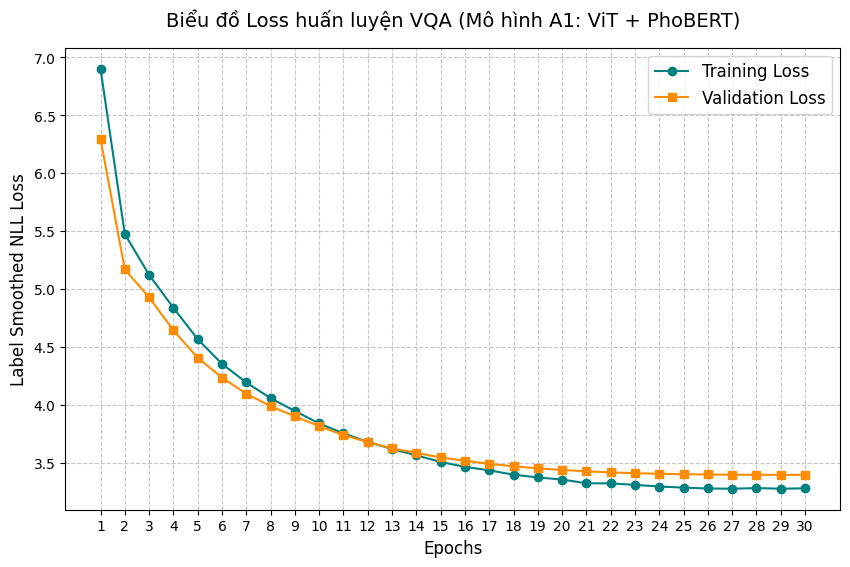

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

# Lấy số epoch thực tế đã chạy (phòng trường hợp bạn dừng sớm)
epochs_run = len(history_train_loss)

# Vẽ 2 đường Loss (đổi màu một chút cho đồ thị trông hiện đại hơn)
plt.plot(range(1, epochs_run + 1), history_train_loss, label='Training Loss', color='teal', marker='o')
plt.plot(range(1, epochs_run + 1), history_val_loss, label='Validation Loss', color='darkorange', marker='s')

# Trang trí đồ thị cho báo cáo
plt.title('Biểu đồ Loss huấn luyện VQA (Mô hình A1: ViT + PhoBERT)', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Label Smoothed NLL Loss', fontsize=12)
plt.xticks(range(1, epochs_run + 1)) # Đảm bảo trục X hiển thị số nguyên
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Lưu hình vào Drive
PLOT_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'loss_plot_A1_vit_phobert.png')
plt.savefig(PLOT_SAVE_PATH, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ vào: {PLOT_SAVE_PATH}")

plt.show()

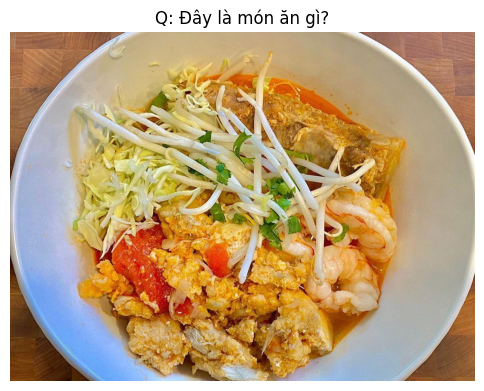

AI Trả lời: bún riêu
Đáp án đúng: Bún riêu.


In [ ]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def predict_a1_vit_phobert(image_path, question_text, model, vocab, device, max_len=15):
    if os.path.exists(MODEL_SAVE_PATH):
        model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
        model.eval()
    else:
        print(f"Lỗi: Không tìm thấy file tại {MODEL_SAVE_PATH}")
        return

    image = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(image).unsqueeze(0).to(device)

    encoded_q = tokenizer(question_text, return_tensors='pt', truncation=True, max_length=50)
    input_ids = encoded_q['input_ids'].to(device)
    attention_mask = encoded_q['attention_mask'].to(device)

    predicted_words = []
    alphas = []

    with torch.no_grad():
        h_d, c_d, features = model(img_tensor, input_ids, attention_mask)
        current_word_idx = torch.tensor([vocab.stoi["<SOS>"]]).to(device)

        for t in range(max_len):
            context, alpha = model.attention(features, h_d[0])
            alphas.append(alpha.cpu().numpy())

            word_embed = model.embedding(current_word_idx)
            step_input = torch.cat([word_embed, context], dim=1)

            new_h, new_c = [], []
            curr_input = step_input
            for i, cell in enumerate(model.decoder_cell):
                h_i, c_i = cell(curr_input, (h_d[i], c_d[i]))
                new_h.append(h_i)
                new_c.append(c_i)
                curr_input = h_i

            h_d, c_d = new_h, new_c

            logits = model.vocab_classifier(model.dropout(h_d[-1]))
            _, next_word_idx = torch.max(logits, dim=1)
            word = vocab.itos[next_word_idx.item()]

            if word == "<EOS>":
                break

            predicted_words.append(word)
            current_word_idx = next_word_idx

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Q: {question_text}")
    plt.axis('off')
    plt.show()

    print(f"AI Trả lời: {' '.join(predicted_words)}")
    return predicted_words, alphas

test_row = df.sample(1).iloc[0]
img_name = test_row['image_path'].split('images/')[-1] if test_row['image_path'].startswith('images/') else test_row['image_path']
test_img_path = os.path.join(IMG_DIR, img_name)

pred, _ = predict_a1_vit_phobert(test_img_path, test_row['question'], model, vocab, device)
print(f"Đáp án đúng: {test_row['answer']}")

⏳ Đang khởi tạo mô hình và tải trọng số đã lưu...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Đã tải trọng số từ: /content/drive/MyDrive/VQA_MonAnVietNam/weights/vqa_model_A1_vit_phobert.pth

  🖼️  HỆ THỐNG HỎI-ĐÁP TRỰC QUAN (VQA) - MÔ HÌNH A1
  🔎  Diverse Beam Search  |  3 nhóm × 2 beam = 6 beam
       max_len=15  |  alpha=0.7  |  gamma=0.5
  Lệnh đặc biệt khi nhập câu hỏi:
    📷  new   → upload ảnh mới
    🚪  thoat → kết thúc chương trình

📂 Tải lên ảnh để bắt đầu:


Saving cach-lam-banh-khot-1_06187869db3b4e878857e0587f3a1c09.jpg to cach-lam-banh-khot-1_06187869db3b4e878857e0587f3a1c09 (2).jpg


/tmp/ipykernel_10331/4254531278.py:179: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


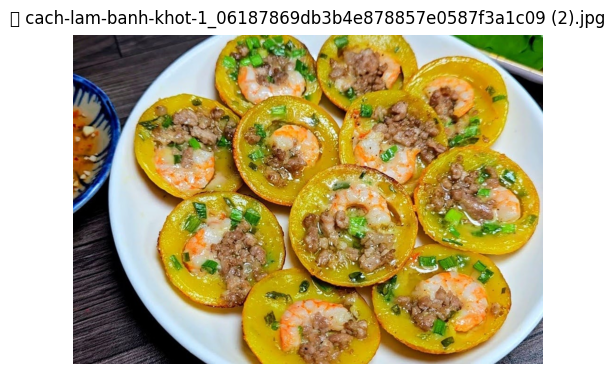


❓ Câu hỏi (new = ảnh mới | thoat = thoát): đây là món ăn gì
────────────────────────────────────────────────────────
  🤖  bún đậu mắm tôm
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): bánh được đặt ở đâu
────────────────────────────────────────────────────────
  🤖  bánh được đặt trên một chiếc đĩa màu trắng
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): thành phần trên bánh có gì
────────────────────────────────────────────────────────
  🤖  đó là hành lá được cắt nhỏ
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): đĩa có màu gì
────────────────────────────────────────────────────────
  🤖  màu xanh lá cây
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): có tôm không
────────────────────────────────────────────────────────
  🤖  có có tôm và hành lá
────────────────────────────

Saving Screenshot 2026-04-24 092549.png to Screenshot 2026-04-24 092549 (1).png


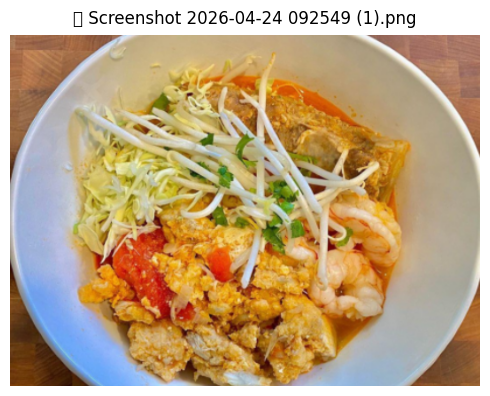


❓ Câu hỏi (new = ảnh mới | thoat = thoát): đây là món ăn gì
────────────────────────────────────────────────────────
  🤖  bún đậu mắm tôm
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): nước dùng có màu gì
────────────────────────────────────────────────────────
  🤖  màu xanh lá cây
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): món này có tôm không
────────────────────────────────────────────────────────
  🤖  có
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): thành phần ở trên có gì
────────────────────────────────────────────────────────
  🤖  thịt heo thái lát
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ảnh mới | thoat = thoát): bát có màu gì
────────────────────────────────────────────────────────
  🤖  màu xanh lá cây
────────────────────────────────────────────────────────

❓ Câu hỏi (new = ản

In [8]:
# ============================================================
# 🔍 CELL SUY LUẬN (INFERENCE) - KHÔNG CẦN TRAIN LẠI
# Chạy cell này SAU KHI đã chạy: Cell 0 (setup), Cell 1 (Vocab),
# Cell 2 (Transforms + Dataset), Cell 3 (Model class)
# ============================================================

import os
import io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from transformers import AutoTokenizer

# ── 1. KHỞI TẠO LẠI MÔ HÌNH VÀ TẢI TRỌNG SỐ ──────────────────────────────
print("⏳ Đang khởi tạo mô hình và tải trọng số đã lưu...")

EMBED_SIZE  = 512
HIDDEN_SIZE = 1024
NUM_LAYERS  = 2

inference_model = VQA_A1_ViT_PhoBERT_Model(
    vocab_size   = len(vocab),
    embed_size   = EMBED_SIZE,
    hidden_size  = HIDDEN_SIZE,
    num_layers   = NUM_LAYERS,
    dropout_rate = 0.0
).to(device)

MODEL_SAVE_PATH = os.path.join(WEIGHTS_DIR, 'vqa_model_A1_vit_phobert.pth')

if not os.path.exists(MODEL_SAVE_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy file trọng số tại:\n  {MODEL_SAVE_PATH}\n"
        "Hãy kiểm tra lại đường dẫn WEIGHTS_DIR."
    )

inference_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
inference_model.eval()
print(f"✅ Đã tải trọng số từ: {MODEL_SAVE_PATH}\n")

# ── 2. TOKENIZER ─────────────────────────────────────────────────────────────
infer_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# ── 3. THAM SỐ INFERENCE ─────────────────────────────────────────────────────
NUM_GROUPS      = 3     # Số nhóm beam (diversity groups)
BEAMS_PER_GROUP = 2     # Số beam trong mỗi nhóm → tổng beam = NUM_GROUPS * BEAMS_PER_GROUP
MAX_LEN         = 15    # Số từ tối đa cho câu trả lời
LENGTH_ALPHA    = 0.7   # Length penalty: 0.0 = tắt, 0.6~0.9 = câu dài hơn
DIVERSITY_GAMMA = 0.5   # Penalty đa dạng giữa các nhóm: tăng → các nhóm khác nhau hơn

# ── 4. HÀM DECODER MỘT BƯỚC ─────────────────────────────────────────────────
def decoder_step(current_word_idx, h_d, c_d, features):
    """Chạy một bước decoder, trả về log_probs và hidden state mới."""
    with torch.no_grad():
        context, _  = inference_model.attention(features, h_d[0])
        word_embed  = inference_model.embedding(current_word_idx)
        step_input  = torch.cat([word_embed, context], dim=1)

        new_h, new_c = [], []
        curr_input = step_input
        for i, cell in enumerate(inference_model.decoder_cell):
            h_i, c_i = cell(curr_input, (h_d[i], c_d[i]))
            new_h.append(h_i)
            new_c.append(c_i)
            curr_input = h_i

        logits   = inference_model.vocab_classifier(new_h[-1])
        log_prob = F.log_softmax(logits, dim=1)

    return log_prob, new_h, new_c

def length_penalized_score(score, length, alpha=LENGTH_ALPHA):
    return score / (length ** alpha) if length > 0 else score

# ── 5. HÀM INFERENCE (DIVERSE BEAM SEARCH) ───────────────────────────────────
def infer_diverse_beam(image_pil, question_text,
                       max_len=MAX_LEN,
                       num_groups=NUM_GROUPS,
                       beams_per_group=BEAMS_PER_GROUP,
                       diversity_gamma=DIVERSITY_GAMMA):
    """
    Diverse Beam Search: chia beam thành num_groups nhóm độc lập.
    Mỗi nhóm bị phạt nếu chọn từ đã được nhóm trước chọn trong cùng bước
    → các nhóm khám phá những hướng khác nhau của không gian tìm kiếm.
    Kết quả cuối là beam tốt nhất trên tất cả các nhóm.
    """
    img_tensor = val_transform(image_pil).unsqueeze(0).to(device)

    encoded_q = infer_tokenizer(
        question_text,
        return_tensors='pt',
        truncation=True,
        max_length=50,
        padding='max_length'
    )
    input_ids      = encoded_q['input_ids'].to(device)
    attention_mask = encoded_q['attention_mask'].to(device)

    with torch.no_grad():
        h_d_init, c_d_init, features = inference_model(img_tensor, input_ids, attention_mask)

    # Khởi tạo các nhóm beam — mỗi nhóm bắt đầu từ cùng trạng thái
    # groups[g] = list of (score, words, h_d, c_d)
    groups = [
        [(0.0, [], h_d_init, c_d_init)]
        for _ in range(num_groups)
    ]
    completed = []   # tất cả beam đã kết thúc từ mọi nhóm

    for _ in range(max_len):
        # Tập hợp token đã được các nhóm trước chọn trong bước này
        tokens_chosen_this_step = []

        for g in range(num_groups):
            candidates = []

            for score, words, h_d, c_d in groups[g]:
                last_token = vocab.stoi["<SOS>"] if not words                              else vocab.stoi.get(words[-1], vocab.stoi["<UNK>"])
                current_word_idx = torch.tensor([last_token]).to(device)

                log_prob, new_h, new_c = decoder_step(
                    current_word_idx, h_d, c_d, features
                )

                # Áp dụng diversity penalty: giảm điểm các token đã được
                # nhóm trước lựa chọn trong cùng bước này
                penalized_log_prob = log_prob[0].clone()
                for prev_token_idx in tokens_chosen_this_step:
                    penalized_log_prob[prev_token_idx] -= diversity_gamma

                topk_scores, topk_idxs = penalized_log_prob.topk(beams_per_group)
                for lp, idx in zip(topk_scores, topk_idxs):
                    word      = vocab.itos[idx.item()]
                    new_score = score + log_prob[0][idx].item()  # điểm thật (không penalty)
                    if word == "<EOS>":
                        completed.append((new_score, words))
                    else:
                        candidates.append((new_score, words + [word], new_h, new_c))
                        tokens_chosen_this_step.append(idx.item())

            if not candidates:
                groups[g] = []
                continue

            candidates.sort(
                key=lambda x: length_penalized_score(x[0], len(x[1])),
                reverse=True
            )
            groups[g] = candidates[:beams_per_group]

        # Dừng sớm nếu tất cả nhóm đều rỗng
        if all(len(g) == 0 for g in groups):
            break

    # Gom tất cả beam còn lại chưa kết thúc vào completed
    for group in groups:
        for score, words, _, _ in group:
            if words:
                completed.append((score, words))

    if not completed:
        return "(không có câu trả lời)"

    # Chọn beam tốt nhất theo length-penalized score
    completed.sort(
        key=lambda x: length_penalized_score(x[0], len(x[1])),
        reverse=True
    )
    return " ".join(completed[0][1])

def show_image(image_pil, title=""):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image_pil)
    if title:
        ax.set_title(title, fontsize=12, pad=8)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── 6. VÒNG LẶP HỎI-ĐÁP ─────────────────────────────────────────────────────
total_beams = NUM_GROUPS * BEAMS_PER_GROUP
print("=" * 56)
print("  🖼️  HỆ THỐNG HỎI-ĐÁP TRỰC QUAN (VQA) - MÔ HÌNH A1")
print(f"  🔎  Diverse Beam Search  |  {NUM_GROUPS} nhóm × {BEAMS_PER_GROUP} beam = {total_beams} beam")
print(f"       max_len={MAX_LEN}  |  alpha={LENGTH_ALPHA}  |  gamma={DIVERSITY_GAMMA}")
print("=" * 56)
print("  Lệnh đặc biệt khi nhập câu hỏi:")
print("    📷  new   → upload ảnh mới")
print("    🚪  thoat → kết thúc chương trình")
print("=" * 56)

current_image = None

while True:
    if current_image is None:
        print("\n📂 Tải lên ảnh để bắt đầu:")
        uploaded = files.upload()
        if not uploaded:
            print("⚠️  Không có file nào được tải lên. Thoát.")
            break
        filename = list(uploaded.keys())[0]
        try:
            current_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
        except Exception as e:
            print(f"❌ Không thể đọc ảnh: {e}")
            continue
        show_image(current_image, title=f"📷 {filename}")

    question = input("\n❓ Câu hỏi (new = ảnh mới | thoat = thoát): ").strip()

    if question.lower() in ["thoat", "exit", "quit"]:
        print("\n👋 Đã dừng chương trình.")
        break

    if question.lower() == "new":
        current_image = None
        print("─" * 56)
        continue

    if question == "":
        print("⚠️  Vui lòng nhập câu hỏi.")
        continue

    answer = infer_diverse_beam(current_image, question)
    print("─" * 56)
    print(f"  🤖  {answer}")
    print("─" * 56)


In [ ]:
!pip install -q bert-score transformers
!pip install -q rouge-score bert-score nltk transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from tqdm.auto import tqdm

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

def evaluate_vqa_metrics(model, val_dataset, vocab, device, max_len=15):
    model.eval()
    predictions_str = []
    references_str = []

    print("Đang chạy suy luận trên tập Validation với ViT + PhoBERT...")

    with torch.no_grad():
        for idx in tqdm(range(len(val_dataset)), desc="Dự đoán"):
            image, input_ids, attention_mask, answer_tensor = val_dataset[idx]

            img_tensor = image.unsqueeze(0).to(device)
            input_ids = input_ids.unsqueeze(0).to(device)
            attention_mask = attention_mask.unsqueeze(0).to(device)

            h_d, c_d, features = model(img_tensor, input_ids, attention_mask)
            current_word_idx = torch.tensor([vocab.stoi["<SOS>"]]).to(device)
            pred_words = []

            for _ in range(max_len):
                context, _ = model.attention(features, h_d[0])
                word_embed = model.embedding(current_word_idx)
                step_input = torch.cat([word_embed, context], dim=1)

                new_h, new_c = [], []
                curr_input = step_input
                for i, cell in enumerate(model.decoder_cell):
                    h_i, c_i = cell(curr_input, (h_d[i], c_d[i]))
                    new_h.append(h_i)
                    new_c.append(c_i)
                    curr_input = h_i

                h_d, c_d = new_h, new_c
                logits = model.vocab_classifier(model.dropout(h_d[-1]))
                _, next_word_idx = torch.max(logits, dim=1)

                word = vocab.itos[next_word_idx.item()]
                if word == "<EOS>":
                    break
                pred_words.append(word)
                current_word_idx = next_word_idx

            predictions_str.append(" ".join(pred_words))

            ref_words = [vocab.itos[t.item()] for t in answer_tensor
                         if vocab.itos[t.item()] not in ["<SOS>", "<EOS>", "<PAD>"]]
            references_str.append(" ".join(ref_words))

    print("\n" + "="*55)
    print(" KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (ViT + PhoBERT) ")
    print("="*55)

    nltk_preds = [pred.split() for pred in predictions_str]
    nltk_refs = [[ref.split()] for ref in references_str]
    chencherry = SmoothingFunction()

    bleu1 = corpus_bleu(nltk_refs, nltk_preds, weights=(1, 0, 0, 0), smoothing_function=chencherry.method1)
    print(f"1. BLEU-1 Score:       {bleu1 * 100:.2f} / 100")

    bleu4 = corpus_bleu(nltk_refs, nltk_preds, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)
    print(f"2. BLEU-4 Score:       {bleu4 * 100:.2f} / 100")

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_scores = [scorer.score(ref, pred)['rougeL'].fmeasure for pred, ref in zip(predictions_str, references_str)]
    avg_rouge = sum(rouge_scores) / len(rouge_scores) if rouge_scores else 0
    print(f"3. ROUGE-L F1:         {avg_rouge * 100:.2f} / 100")

    meteor_scores = [meteor_score([ref.split()], pred.split()) for pred, ref in zip(predictions_str, references_str)]
    avg_meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0
    print(f"4. METEOR Score:       {avg_meteor * 100:.2f} / 100")

    print("\nĐang tính toán BERTScore...")
    P, R, F1 = bert_score(predictions_str, references_str, lang="vi", model_type="bert-base-multilingual-cased", verbose=False)
    avg_bert_f1 = F1.mean().item()
    print(f"5. BERTScore (F1):     {avg_bert_f1 * 100:.2f} / 100")

    print("="*55)

evaluate_vqa_metrics(model, val_dataset, vocab, device)

Đang chạy suy luận trên tập Validation với ViT + PhoBERT...


Dự đoán:   0%|          | 0/1261 [00:00<?, ?it/s]


 KẾT QUẢ ĐÁNH GIÁ CHI TIẾT (ViT + PhoBERT) 
1. BLEU-1 Score:       23.32 / 100
2. BLEU-4 Score:       7.44 / 100
3. ROUGE-L F1:         35.11 / 100
4. METEOR Score:       19.45 / 100

Đang tính toán BERTScore...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


5. BERTScore (F1):     76.84 / 100
